# 

## 1. Start With the Model
Import the Decision Tree Classfier:

In [131]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [132]:
df = pd.read_csv("../dataset/titanic/train.csv")

In [133]:
X = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
].copy()

y = df["Survived"]

### Encode categorical columns

In [134]:
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

### Handle missing values

In [135]:
X["Age"] = X["Age"].fillna(X["Age"].median())

Create the model:

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [137]:
model = DecisionTreeClassifier(
    random_state = 42
)

Train it:

In [138]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Generate predictions:

In [139]:
predict = model.predict(X_test)

## 2. Evaluate the Model
Use the accuracy metric you learned earlier:

In [140]:
accuracy = accuracy_score(y_test, predict)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.7821229050279329


But do not stop here.

For a real ML engineer, one number is not enough.

## 3. Measure Training Performance Too
Calculate both:

In [141]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9789325842696629
Test Accuracy: 0.7821229050279329


Now ask:

What do these two numbers tell you?

Suppose you get:

Training Accuracy: 1.00

Test Accuracy:     0.82

The model performs perfectly on training data but considerably worse on unseen data.

That is a classic sign of:

Overfitting

The tree has become too specialized to the training data.

# FULL CODE

In [142]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("../dataset/titanic/train.csv")

X = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
].copy()

y = df["Survived"]

X = pd.get_dummies(
    X,
    columns = ["Sex", "Embarked"],
    drop_first = True
)


X["Age"] = X["Age"].fillna(X["Age"].median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)


model = DecisionTreeClassifier(
    random_state = 42
)


model.fit(X_train, y_train)


predictions = model.predict(X_test)


accuracy = accuracy_score(y_test, predictions)

print("Test Accuracy:", accuracy)


train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7821229050279329
Training Accuracy: 0.9789325842696629
Test Accuracy: 0.7821229050279329


## 4. Your Main Experiment — max_depth
This is today's most important experiment.

Train multiple trees:

In [143]:
depths = [1, 2, 3, 5, 10]

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth = depth,
        random_state = 42
    )

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    print(
        "Depth:", depth,
        "| Train:", round(train_accuracy, 3),
        "| Test:", round(test_accuracy, 3)
    )

Depth: 1 | Train: 0.788 | Test: 0.782


Depth: 2 | Train: 0.803 | Test: 0.765
Depth: 3 | Train: 0.834 | Test: 0.799
Depth: 5 | Train: 0.851 | Test: 0.799
Depth: 10 | Train: 0.913 | Test: 0.793


## 9. Optional Visualization
Once the model is trained, you can visualize the tree:

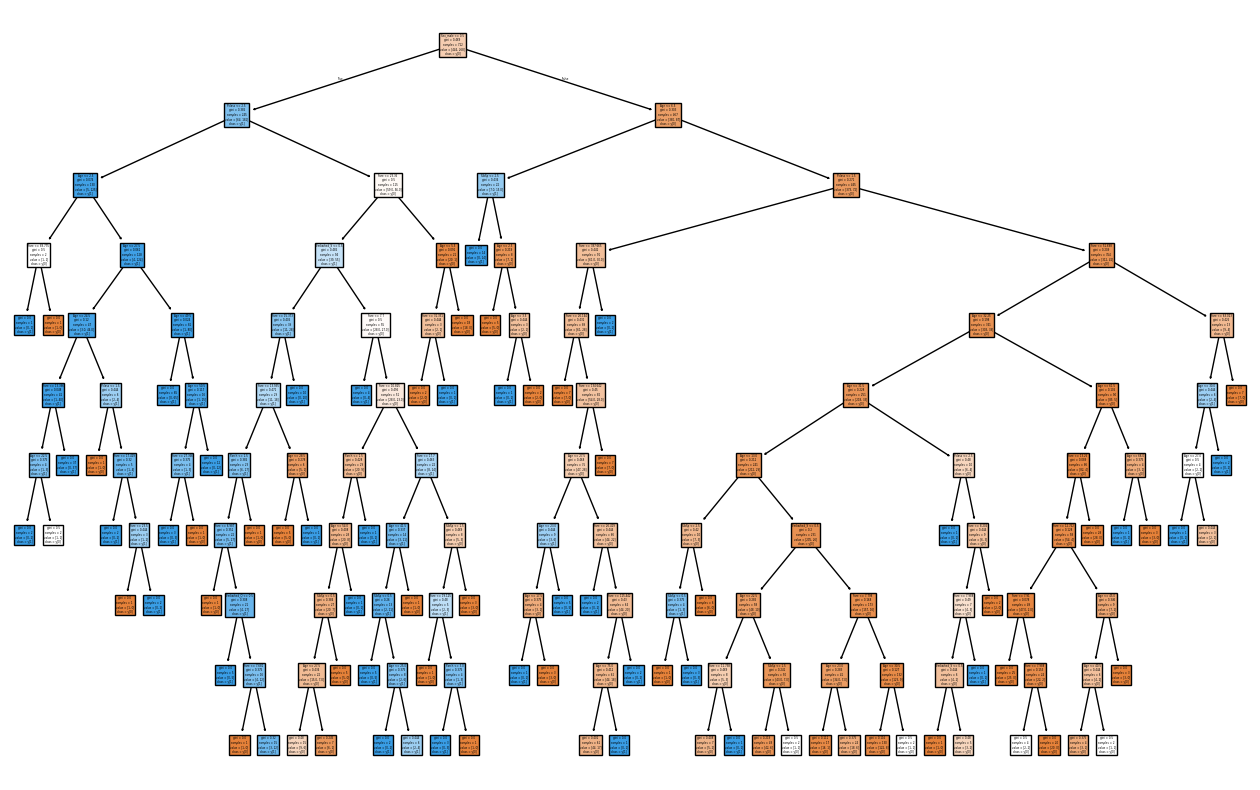

In [144]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

plot_tree(
    model,
    filled=True,
    feature_names=X_train.columns,
    class_names=True
)

plt.show()

Your goal is not artistic visualization.

Your goal is to look at the tree and understand that it is creating a sequence of decisions.

## DAY 4 CHALLENGE
Build a reusable experiment:

In [145]:
def evaluate_tree(depth):

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    return train_acc, test_acc

### Then:

In [146]:
for depth in [1, 2, 3, 5, 10]:

    train_acc, test_acc = evaluate_tree(depth)

    print(
        f"Depth={depth} | "
        f"Train={train_acc:.3f} | "
        f"Test={test_acc:.3f}"
    )

Depth=1 | Train=0.788 | Test=0.782
Depth=2 | Train=0.803 | Test=0.765
Depth=3 | Train=0.834 | Test=0.799
Depth=5 | Train=0.851 | Test=0.799
Depth=10 | Train=0.913 | Test=0.793


This small exercise is valuable because you are beginning to think in terms of experiments, not just individual code snippets.